In [1]:
import sys
import os
import glob
sys.path.append('/Volumes/T7/Software')
from cardpy.Sample_Data.Data_Paths import *
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *
from cardpy.Data_Processing.DTI    import *
from cardpy.GUI_Tools              import IntERCOMS

from cardpy.Colormaps              import *
from cardpy.Data_Saving            import *
from cardpy.Data_Processing.cDTI   import *
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import SimpleITK as sitk

cDTI_cmaps     = cDTI_Colormaps_Generator()

/Users/saschastocker/Documents/Stanford/DanEnnis20242025/Paper2025Automatic/HAanalysis/Volunteer_01/Distortion_Corrected/DiVO_12_05/NifTis
/Users/saschastocker/Documents/Stanford/DanEnnis20242025/Paper2025Automatic/HAanalysis/Volunteer_01/Distortion_Corrected/DiVO_12_05/NifTis/*Interpolated
(200, 200, 3, 13)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/dipy/reconst/dti.py:497: RuntimeWarning: invalid value encountered in divide
  return 3 * np.sqrt(6) * determinant((A_squiggle / A_s_norm))


(200, 200, 3)
(200, 200)
(200, 200, 1)
Autoadjust Epicardium
Autoadjust Epicardium
Autoadjust Epicardium
Autoadjust Endocardium
Autoadjust Endocardium
Autoadjust Endocardium


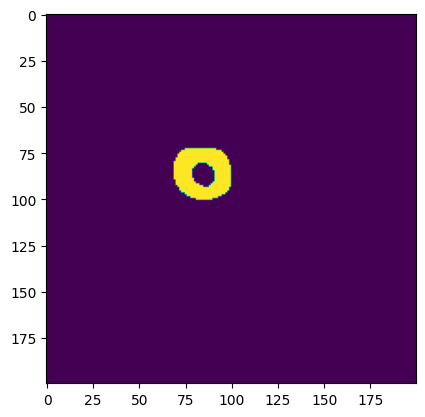

In [2]:
main_path                = sample_Output_Folder() #old line default?

#smb://171.65.44.79/rslva-raid/Summer_of_Segmentation_2024/Smart_Health/Volunteer_10/Distortion_Corrected/DiVO_15_04/NifTis/Interpolated.bvals

#On original!!! so outside the hanum file, on the raw aquired data
main_path = '/Users/saschastocker/Documents/Stanford/DanEnnis20242025/Paper2025Automatic/HAanalysis/Volunteer_01/Distortion_Corrected/DiVO_12_05/NifTis'
print(main_path)
print(f'{os.path.join(main_path, '*Interpolated')}')
NifTi_path               = glob.glob(os.path.join(main_path, '*.nii'))[0]
header_path              = glob.glob(os.path.join(main_path, '*.header'))[0]
b_values_path            = glob.glob(os.path.join(main_path, '*.bvals'))[0]
b_vectors_path           = glob.glob(os.path.join(main_path,  '*.bvecs'))[0]

Segmentaiton_Path        = os.path.join(main_path, '11_Segmentation')
if os.path.isdir(Segmentaiton_Path) == False:
    os.makedirs(Segmentaiton_Path)
Quantiative_Results_Path = os.path.join(main_path, '12_Quantitative_Results')
if os.path.isdir(Quantiative_Results_Path) == False:
    os.makedirs(Quantiative_Results_Path)

[matrix_stacked, b_vals_stacked, b_vecs_stacked, Header, _, _] = NifTi_Reader(NifTi_path, b_values_path, b_vectors_path, header_path)

#Nifit file has all 3 slices, so choose the slice based on the voliunter path!! but then use on shape eg. diret access the tensor!
print(matrix_stacked.shape)
matrix_stacked = matrix_stacked[:,:,0,:]
matrix_stacked = matrix_stacked[:,:,np.newaxis,:]

[matrix_sorted,  b_vals_sorted,  b_vecs_sorted]                = stacked2sorted(matrix_stacked, b_vals_stacked, b_vecs_stacked)
[_, _, Eigenvectors, Standard_DTI_Metrics]                     = DTI_recon(matrix_sorted, b_vals_sorted, b_vecs_sorted, tensor_fit = 'NLLS')
#[Endo_Centers, Endo_Axes, Epi_Centers, Epi_Axes]               = IntERCOMS.IntERCOMS_GUI(matrix_sorted[:, :, :, 0], Standard_DTI_Metrics['MD'], Eigenvectors['E1'], Line_Width = 1)
#[myocardium_mask, NRRD2, NRRD1]                                = IntERCOMS.IntERCOMS_Mask_Making(matrix_sorted, Endo_Centers, Endo_Axes, Epi_Centers, Epi_Axes)
#Save_NRRD_Segmentation(NRRD1, Header, Segmentaiton_Path, 'LV_Blood_Pool')
#Save_NRRD_Segmentation(NRRD2, Header, Segmentaiton_Path, 'LV_Myocardium+Blood_Pool')


myocardium_mask = sitk.ReadImage( '/Users/saschastocker/Documents/Stanford/DanEnnis20242025/WholeHeartCropISMRM/Summer_of_Segmentation_2024/Directions_vs_Averages_Data/Hannum/Volunteer_01/Distortion_Corrected/DiVO_06_10/04_Segmentation_Masks/Segmentation_Slice_001.nii')
print(myocardium_mask.GetSize())
myocardial_mask              = sitk.GetArrayFromImage(myocardium_mask[:,:,0])
print(myocardial_mask.shape)
#myocardial_mask = np.transpose(myocardial_mask, [1,2,0])
myocardial_mask = np.nan_to_num(myocardial_mask)[:,:,np.newaxis]
print(myocardial_mask.shape)
plt.imshow(myocardial_mask)

# image = myocardial_mask
num_interp_points            = 200
#Tyler -> changed from medium to native, so it doesn't interoplate the mask, and doesn't smooth it out, double check:... tbd
#Should get the raw masks, because trainnig is done on smoothed images so we compare the two outputs on the raw afterwards!
smoothness_level             = 'Native'
Helix_Angle_Filter_Settings  = dict()
Helix_Angle_Filter_Settings['Linear Filter: Outlier StDev']      = 1
Helix_Angle_Filter_Settings['Spatial Filter: Wall Depth Factor'] = 0.25
Helix_Angle_Filter_Settings['Spatial Filter: Kernel Size']       = 5


#mask is either GT or predicted!!, so need to run one for GT and one for pred!
#split here... eg. make function out of above here, and then do the same for GT and prediciton.
#....


[Cardiac_DTI_Metrics, Epi, Endo, Mask] = cDTI_recon(myocardial_mask, Eigenvectors, num_interp_points, smoothness_level, Helix_Angle_Filter_Settings)


#Cardiac_DTI_Metrics -> DICTIONAIRY of different maps includingthe HA!!!


myocardial_mask_smoothed = np.copy(Mask)
#if native, smoothness and regular one should be equal

#UNSURE WHAT THIS DOES BUT BUGGS ATM!!! :TODO
# if (myocardial_mask == myocardial_mask_smoothed):
#     print('smoothness level is set to native, so check should pass!')

# else:
#     print('some smoothenss is happneing on the masks.... double check')
#     #maybe set to low/ medium,  otherwise save as a new smoothed or something.. as an 07 folder in the orignal folder strucutre and then do the HAP assesmetnnow    
#     #if this trigers we have ot use the smoothed one for MD FA etc. too!
#     #could also save this as excel.. first check if trigger even happens.


myocardial_mask_smoothed_nan = np.copy(myocardial_mask_smoothed)
myocardial_mask_smoothed_nan = myocardial_mask_smoothed_nan.astype('float')

myocardial_mask_smoothed_nan [myocardial_mask_smoothed_nan == 0] = np.nan

grid     = Endo2Epi_Grid(myocardial_mask_smoothed)
grid_nan = np.copy(grid)
grid_nan = grid_nan * myocardial_mask_smoothed_nan
grid_nan = np.clip(grid_nan, 0.0, 1)
matrix   = matrix_sorted

#what we want to save:
#Standard_DTI_Metrics -> mat file, stored as a dictionary atm.
#Cardiac_DTI_Metrics -> ^
#for both GT and predicted!!! so need two!

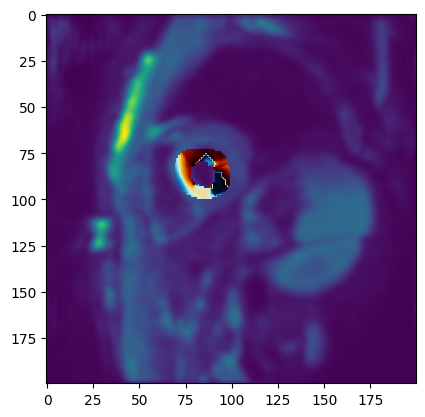

In [3]:
plt.imshow(matrix_sorted[:,:,0,0])
plt.imshow(Cardiac_DTI_Metrics["HA"], vmin = -90, vmax = 90, cmap = cDTI_cmaps["HA"])


In [4]:
#main_path                = sample_Output_Folder()

#main_path = '/Users/saschastocker/Documents/Stanford/DanEnnis20242025/Paper2025Automatic/HAanalysis/Volunteer_01/Distortion_Corrected/DiVO_12_05/NifTis'

for volunteer in os.listdir(main_path):
    if volunteer == '.DS_Store':
        continue
    for dataset in os.listdir(os.path.join(main_path,volunteer)):
        dataset

    
NifTi_path               = glob.glob(os.path.join(main_path, '*Interpolated', '*.nii'))[0]
header_path              = glob.glob(os.path.join(main_path, '*Interpolated', '*.header'))[0]
b_values_path            = glob.glob(os.path.join(main_path, '*Interpolated', '*.bvals'))[0]
b_vectors_path           = glob.glob(os.path.join(main_path, '*Interpolated', '*.bvecs'))[0]
#map to the data we pull in from the orignal images from folders
input_path_data = ""

#use for later integration in the segmentaiotn analysis
input_path_segmentation = ""


NotADirectoryError: [Errno 20] Not a directory: '/Users/saschastocker/Documents/Stanford/DanEnnis20242025/Paper2025Automatic/HAanalysis/Volunteer_01/Distortion_Corrected/DiVO_12_05/NifTis/Interpolated.bvals'

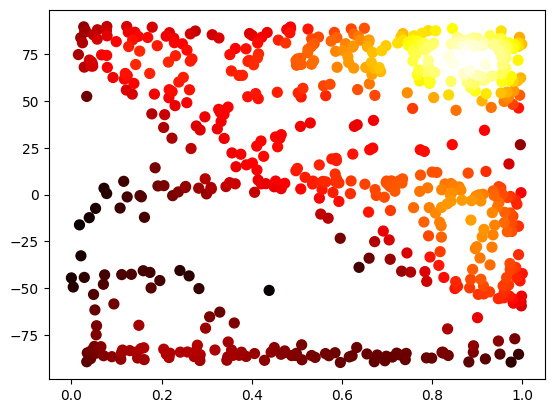

In [5]:
#/Users/saschastocker/Documents/Stanford/DanEnnis20242025/Paper2025Automatic/HAanalysis/Volunteer_01/Distortion_Corrected/DiVO_12_05/NifTis

from sklearn.linear_model import LinearRegression
from scipy.stats          import gaussian_kde

HAP_gt = []
HAR_gt = []

for slc in range(myocardial_mask_smoothed_nan.shape[2]):
    E2E_data = grid_nan[:, :, slc].flatten()
    E2E_data = E2E_data[~(np.isnan(grid_nan[:, :, slc].flatten()))]
    x = E2E_data
    xi = np.copy(x)



    HA_data  = Cardiac_DTI_Metrics['HA'][:, :, slc].flatten()
    HA_data  = HA_data[~(np.isnan(grid_nan[:, :, slc].flatten()))]
    y = HA_data
    yi = np.copy(y)

    # Calculate the point density
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)

    # Sort the points by density, so that the densest points are plotted last
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    density = plt.scatter(x, y, c=z, s=50, cmap = 'hot')


    model                 = LinearRegression().fit(x[:, np.newaxis], y[:, np.newaxis])
    #enforcing true 0 and true 1, true epi and endo endpoint/limit
    x_predicted = np.linspace(0,1, 101)
    y_predicted = model.intercept_ + model.coef_ * x_predicted[:, np.newaxis]

    #adds the helix angle pitches from each slice
    HAP_gt.append(model.coef_)
    #-> extract THIS angle for comparison of GT slope vs. prediction derived slope!!!
    #Should be a nice regression LINE with slope. Compare the two slopes, of predicted and
    #save into csv format

    #get the ranges, positive - (negative) -> range of the angles.
    HAR_gt.append(y_predicted[0]-y_predicted[-1])
    #range can be another one number! metric  -> Max - min!


# #repeat for predicted mask TODO!
# HAP_pred..
# HAR_pred....
#compare -> similar to MD and FA maps comparison... should be super close otherwise the segmentation is off
#can compare the pitches or the ranges, depending on what's more tellling/ better to look at.
    

